In [397]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.font_manager as fm
import matplotlib

font_path = 'C:\\Windows\\Fonts\\gulim.ttc'
font = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font)

In [398]:
# 파일 읽기 / 날씨 데이터와 전력량 데이터 (2015~2024)
weather_df = pd.read_csv('./data/weather_data_201501_202412.csv', encoding='cp949')
electric_df = pd.read_csv('./data/elect_2015_2024.csv',encoding='cp949')

In [399]:
# unamed 컬럼 제외
electric_df = electric_df.drop(electric_df.columns[0],axis=1)

# 일시에서 월(month)뽑기
weather_df['월'] = pd.to_datetime(weather_df['일시']).dt.month.astype(int)

# 일시, 년(year)으로 교체
weather_df['일시'] =  pd.to_datetime(weather_df['일시']).dt.strftime('%Y').astype(int)

# 결측값 0으로 채우기 
weather_df['최심적설(cm)'] = weather_df['최심적설(cm)'].fillna(0)

# 일시를 연도로 바꾸기 - 뒤에 전력량과 맞춰주기 위하여
weather_df = weather_df.rename(columns={'일시':'연도'})

weather_df


,지점,지점명,연도,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C),월
0,90,속초,2015,1.8,1019.8,1022.1,3.7,52.0,8.7,2.2,60.79,3.0,1.2,1
1,90,속초,2015,2.4,1018.0,1020.2,4.4,59.0,32.1,2.5,62.81,8.7,2.3,2
2,90,속초,2015,6.6,1017.0,1019.2,5.2,52.0,8.0,2.5,74.49,0.0,8.5,3
3,90,속초,2015,11.1,1014.0,1016.2,8.1,69.0,74.2,2.5,46.87,0.0,12.8,4
4,90,속초,2015,17.8,1005.8,1007.9,11.5,61.0,9.2,2.4,67.60,0.0,23.7,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11418,296,북부산,2024,29.3,1007.4,1007.7,31.8,80.0,73.5,2.3,57.50,0.0,32.0,8
11419,296,북부산,2024,26.5,1013.2,1013.5,26.6,77.0,418.5,2.4,45.68,0.0,28.2,9
11420,296,북부산,2024,19.1,1019.3,1019.7,16.4,75.0,185.0,2.2,37.45,0.0,19.0,10
11421,296,북부산,2024,12.2,1021.4,1021.8,9.9,68.0,82.0,1.7,54.61,0.0,11.8,11


In [400]:
targets = ['파주시', '양평군', '수원시', '동두천시'] 
k_electric_df = electric_df[
    (electric_df['시도'] == '경기도') &
    (electric_df['시군구'].isin(targets))]

i_electric_df = electric_df[electric_df['시도'] == '인천광역시']

ki_electric_df = pd.concat((k_electric_df,i_electric_df))

ki_electric_df

,연도,시도,시군구,계약종별,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
615,2017,경기도,동두천시,주택용,11586588,11532083,10108463,10223892,9586709,9605873,11228284,12397490,10098161,9659357,10354828,11446570
616,2017,경기도,동두천시,일반용,22088657,23486711,18021231,17761821,15098549,17064111,20131714,23086315,19624928,15569106,16738100,21487959
617,2017,경기도,동두천시,교육용,1436688,1408797,1348140,1075218,672078,693838,866822,809108,756327,633878,889747,1712385
618,2017,경기도,동두천시,산업용,21829175,21998405,22717621,22712289,20825650,21264327,21998120,21670970,22863477,20620167,23068561,24110905
619,2017,경기도,동두천시,농사용,841552,917005,685986,583828,493511,500522,560825,717089,696319,562830,717438,903851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18846,2024,인천광역시,옹진군,산업용,4806885,5989423,6939498,4857945,7346787,4915931,5774606,1717590,6230810,3481568,5851174,3465841
18847,2024,인천광역시,옹진군,농사용,1117474,1049024,1212570,1392652,1193452,1224546,1235624,1656702,1830226,1421857,2545962,1541456
18848,2024,인천광역시,옹진군,가로등,184195,170980,154232,139969,127245,119651,121207,131381,141060,157564,171801,185558
18849,2024,인천광역시,옹진군,심 야,2958148,2749580,2150594,1500308,956409,613749,409555,367643,318228,477762,1025505,2078307


In [401]:
i_electric_df['시군구'].unique()
['중구', '동구', '남구', '서구', '남동구', '부평구', '계양구', '연수구', '강화군', '옹진군','미추홀구']

['중구', '동구', '남구', '서구', '남동구', '부평구', '계양구', '연수구', '강화군', '옹진군', '미추홀구']

In [402]:
ki_electric_df

,연도,시도,시군구,계약종별,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
615,2017,경기도,동두천시,주택용,11586588,11532083,10108463,10223892,9586709,9605873,11228284,12397490,10098161,9659357,10354828,11446570
616,2017,경기도,동두천시,일반용,22088657,23486711,18021231,17761821,15098549,17064111,20131714,23086315,19624928,15569106,16738100,21487959
617,2017,경기도,동두천시,교육용,1436688,1408797,1348140,1075218,672078,693838,866822,809108,756327,633878,889747,1712385
618,2017,경기도,동두천시,산업용,21829175,21998405,22717621,22712289,20825650,21264327,21998120,21670970,22863477,20620167,23068561,24110905
619,2017,경기도,동두천시,농사용,841552,917005,685986,583828,493511,500522,560825,717089,696319,562830,717438,903851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18846,2024,인천광역시,옹진군,산업용,4806885,5989423,6939498,4857945,7346787,4915931,5774606,1717590,6230810,3481568,5851174,3465841
18847,2024,인천광역시,옹진군,농사용,1117474,1049024,1212570,1392652,1193452,1224546,1235624,1656702,1830226,1421857,2545962,1541456
18848,2024,인천광역시,옹진군,가로등,184195,170980,154232,139969,127245,119651,121207,131381,141060,157564,171801,185558
18849,2024,인천광역시,옹진군,심 야,2958148,2749580,2150594,1500308,956409,613749,409555,367643,318228,477762,1025505,2078307


In [403]:
# 서울시 주택용 전력량 뽑기

dfs = []

# 각 연도별로 구별 계약종별 데이터 넣기
for y in range(2014,2025):
      incehon_electric_df_year = i_electric_df[i_electric_df['연도'] == y]

      incheon_gu_11 = ['중구', '동구', '남구', '서구', '남동구', '부평구', '계양구', '연수구', '강화군', '옹진군','미추홀구']


        # 구별 데이터 선별
      for gu in incheon_gu_11:
            incheon_electric_df_year_gu = incehon_electric_df_year[incehon_electric_df_year['시군구'] == gu]


            dt_type = ['주택용','일반용','교육용','산업용','농사용','가로등','심 야']


            # 계약별 데이터 선별
            for t in dt_type:
                  incheon_electric_df_year_gu_type = incheon_electric_df_year_gu[incheon_electric_df_year_gu["계약종별"] == t]


                  id_cols = ["연도","시도", "시군구", "계약종별"]
                  month_cols = [ f"{i}월" for i in range(1, 13)]

                    # 멜트해서 id_cols 남기기
                  df_melt = (
                      incheon_electric_df_year_gu_type
                      .reset_index(drop=True)
                      .melt(
                          id_vars=id_cols,
                          value_vars=month_cols,
                          var_name="월",
                          value_name="전력량"
                      )
                  )

                  # 월 숫자만 남기기
                  df_melt["월"] = df_melt["월"].str.replace("월", "").astype(int)
                  dfs.append(df_melt)


# 연도별 구별 월별 데이터 합치기
electric_melt_all = pd.concat(dfs, ignore_index=True)

electric_melt_all

,연도,시도,시군구,계약종별,월,전력량
0,2014,인천광역시,중구,주택용,1,13548722
1,2014,인천광역시,중구,주택용,2,13490518
2,2014,인천광역시,중구,주택용,3,11666665
3,2014,인천광역시,중구,주택용,4,12223277
4,2014,인천광역시,중구,주택용,5,11446641
...,...,...,...,...,...,...
9235,2024,인천광역시,미추홀구,심 야,8,1422285
9236,2024,인천광역시,미추홀구,심 야,9,1175830
9237,2024,인천광역시,미추홀구,심 야,10,781728
9238,2024,인천광역시,미추홀구,심 야,11,602173


In [404]:
dfs1 = []
for y in range(2014,2025):
        ku_electric_df_year = k_electric_df[k_electric_df['연도'] == y]

        dt_type = ['주택용','일반용','교육용','산업용','농사용','가로등','심 야']

        for t in dt_type:
            ki_electric_df_type = ku_electric_df_year[ku_electric_df_year["계약종별"] == t]
            id_cols = ["연도","시도", "시군구", "계약종별"]
            month_cols = [f"{i}월" for i in range(1, 13)]

              # 멜트해서 id_cols 남기기
            df_melt = (
                ki_electric_df_type
                .reset_index(drop=True)
                .melt(
                    id_vars=id_cols,
                    value_vars=month_cols,
                    var_name="월",
                    value_name="전력량"
                )
            )

            # 월 숫자만 남기기
            df_melt["월"] = df_melt["월"].str.replace("월", "").astype(int)
            dfs1.append(df_melt)

electric_melt_all1 = pd.concat(dfs1, ignore_index=True)

electric_melt_all1

,연도,시도,시군구,계약종별,월,전력량
0,2014,경기도,동두천시,주택용,1,11591738
1,2014,경기도,파주시,주택용,1,46464440
2,2014,경기도,양평군,주택용,1,11348046
3,2014,경기도,수원시,주택용,1,134207913
4,2014,경기도,동두천시,주택용,2,11307994
...,...,...,...,...,...,...
3691,2024,경기도,수원시,심 야,11,1582710
3692,2024,경기도,동두천시,심 야,12,1458973
3693,2024,경기도,파주시,심 야,12,10685200
3694,2024,경기도,양평군,심 야,12,21821594


In [405]:
ki_df = pd.concat((electric_melt_all,electric_melt_all1))
ki_df

,연도,시도,시군구,계약종별,월,전력량
0,2014,인천광역시,중구,주택용,1,13548722
1,2014,인천광역시,중구,주택용,2,13490518
2,2014,인천광역시,중구,주택용,3,11666665
3,2014,인천광역시,중구,주택용,4,12223277
4,2014,인천광역시,중구,주택용,5,11446641
...,...,...,...,...,...,...
3691,2024,경기도,수원시,심 야,11,1582710
3692,2024,경기도,동두천시,심 야,12,1458973
3693,2024,경기도,파주시,심 야,12,10685200
3694,2024,경기도,양평군,심 야,12,21821594


In [406]:
weather_ku_df = weather_df[(weather_df['지점명'] == '인천')]
weather_ku_df

,지점,지점명,연도,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C),월
1419,112,인천,2015,-0.8,1015.8,1024.9,4.4,72.0,10.3,3.5,66.75,1.8,-0.1,1
1420,112,인천,2015,1.2,1013.4,1022.5,5.3,75.0,22.8,3.5,64.63,0.4,2.0,2
1421,112,인천,2015,5.4,1012.8,1021.7,6.5,69.0,10.0,3.4,73.10,0.0,6.9,3
1422,112,인천,2015,12.5,1007.4,1016.0,10.4,72.0,53.7,3.5,53.32,0.0,14.0,4
1423,112,인천,2015,17.0,1001.5,1009.8,14.9,78.0,30.1,2.9,66.14,0.0,21.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1534,112,인천,2024,28.8,999.2,1006.9,30.5,78.0,86.7,2.2,56.62,0.0,30.8,8
1535,112,인천,2024,25.4,1004.9,1012.8,24.5,75.0,122.9,2.3,49.23,0.0,26.8,9
1536,112,인천,2024,17.0,1011.7,1019.9,13.4,70.0,82.1,2.2,51.96,0.0,17.6,10
1537,112,인천,2024,9.9,1013.5,1022.0,8.1,63.0,62.2,2.6,58.83,26.0,9.5,11


In [418]:
# # 서울시 날씨 데이터 뽑기
weather_ku_df = weather_df[(weather_df['지점명'] == '인천')| (weather_df['지점명'] == '동두천') | (weather_df['지점명'] == '파주')| (weather_df['지점명'] == '양평')| (weather_df['지점명'] == '수원')]
weather_ku_df = weather_ku_df.rename(columns={'지점명':'시군구'})
weather_ku_df['시도'] = weather_ku_df['시군구'].values
weather_ku_df

,지점,시군구,연도,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C),월,시도
339,98,동두천,2015,-2.3,1010.5,1024.4,3.3,61.0,17.3,1.7,60.91,0.0,-1.5,1,동두천
340,98,동두천,2015,0.1,1008.1,1021.8,3.9,61.0,23.4,1.8,56.67,1.0,0.5,2,동두천
341,98,동두천,2015,5.5,1007.4,1020.9,4.1,46.0,8.4,2.3,70.82,0.2,6.4,3,동두천
342,98,동두천,2015,12.7,1002.5,1015.5,7.4,54.0,82.5,1.9,53.71,0.0,14.2,4,동두천
343,98,동두천,2015,18.3,996.3,1008.9,10.4,53.0,32.8,1.9,64.44,0.0,22.6,5,동두천
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5806,202,양평,2024,27.9,1002.2,1007.5,28.6,78.0,100.0,1.2,54.60,0.0,32.1,8,양평
5807,202,양평,2024,24.2,1008.3,1013.7,23.3,77.0,199.4,1.2,47.06,0.0,27.1,9,양평
5808,202,양평,2024,15.2,1015.1,1020.7,13.6,80.0,105.0,0.9,40.80,0.0,17.7,10,양평
5809,202,양평,2024,8.5,1016.7,1022.5,8.2,73.0,71.7,0.9,52.06,0.0,8.9,11,양평


In [419]:
# 날씨값에서 지점, 지점명, 빼기 (중복 or 불필요)
weather_ku_df_slice = weather_ku_df.iloc[:,1:]
weather_ku_df_slice


,시군구,연도,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C),월,시도
339,동두천,2015,-2.3,1010.5,1024.4,3.3,61.0,17.3,1.7,60.91,0.0,-1.5,1,동두천
340,동두천,2015,0.1,1008.1,1021.8,3.9,61.0,23.4,1.8,56.67,1.0,0.5,2,동두천
341,동두천,2015,5.5,1007.4,1020.9,4.1,46.0,8.4,2.3,70.82,0.2,6.4,3,동두천
342,동두천,2015,12.7,1002.5,1015.5,7.4,54.0,82.5,1.9,53.71,0.0,14.2,4,동두천
343,동두천,2015,18.3,996.3,1008.9,10.4,53.0,32.8,1.9,64.44,0.0,22.6,5,동두천
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5806,양평,2024,27.9,1002.2,1007.5,28.6,78.0,100.0,1.2,54.60,0.0,32.1,8,양평
5807,양평,2024,24.2,1008.3,1013.7,23.3,77.0,199.4,1.2,47.06,0.0,27.1,9,양평
5808,양평,2024,15.2,1015.1,1020.7,13.6,80.0,105.0,0.9,40.80,0.0,17.7,10,양평
5809,양평,2024,8.5,1016.7,1022.5,8.2,73.0,71.7,0.9,52.06,0.0,8.9,11,양평


In [420]:
ki_df['시도'] = ki_df['시도'].str.replace('인천광역시','인천')
ki_df

df = ki_df.merge(weather_ku_df_slice, on=['연도', '월', '시도'])

In [423]:
df

,연도,시도,시군구_x,계약종별,월,전력량,시군구_y,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C)
0,2015,인천,중구,주택용,1,14252330,인천,-0.8,1015.8,1024.9,4.4,72.0,10.3,3.5,66.75,1.8,-0.1
1,2015,인천,중구,주택용,2,13944529,인천,1.2,1013.4,1022.5,5.3,75.0,22.8,3.5,64.63,0.4,2.0
2,2015,인천,중구,주택용,3,12249837,인천,5.4,1012.8,1021.7,6.5,69.0,10.0,3.4,73.10,0.0,6.9
3,2015,인천,중구,주택용,4,12640026,인천,12.5,1007.4,1016.0,10.4,72.0,53.7,3.5,53.32,0.0,14.0
4,2015,인천,중구,주택용,5,11331750,인천,17.0,1001.5,1009.8,14.9,78.0,30.1,2.9,66.14,0.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8395,2024,인천,미추홀구,심 야,8,1422285,인천,28.8,999.2,1006.9,30.5,78.0,86.7,2.2,56.62,0.0,30.8
8396,2024,인천,미추홀구,심 야,9,1175830,인천,25.4,1004.9,1012.8,24.5,75.0,122.9,2.3,49.23,0.0,26.8
8397,2024,인천,미추홀구,심 야,10,781728,인천,17.0,1011.7,1019.9,13.4,70.0,82.1,2.2,51.96,0.0,17.6
8398,2024,인천,미추홀구,심 야,11,602173,인천,9.9,1013.5,1022.0,8.1,63.0,62.2,2.6,58.83,26.0,9.5


In [430]:
weather_ku_df_slice

,시군구,연도,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C),월,시도
339,동두천,2015,-2.3,1010.5,1024.4,3.3,61.0,17.3,1.7,60.91,0.0,-1.5,1,동두천
340,동두천,2015,0.1,1008.1,1021.8,3.9,61.0,23.4,1.8,56.67,1.0,0.5,2,동두천
341,동두천,2015,5.5,1007.4,1020.9,4.1,46.0,8.4,2.3,70.82,0.2,6.4,3,동두천
342,동두천,2015,12.7,1002.5,1015.5,7.4,54.0,82.5,1.9,53.71,0.0,14.2,4,동두천
343,동두천,2015,18.3,996.3,1008.9,10.4,53.0,32.8,1.9,64.44,0.0,22.6,5,동두천
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5806,양평,2024,27.9,1002.2,1007.5,28.6,78.0,100.0,1.2,54.60,0.0,32.1,8,양평
5807,양평,2024,24.2,1008.3,1013.7,23.3,77.0,199.4,1.2,47.06,0.0,27.1,9,양평
5808,양평,2024,15.2,1015.1,1020.7,13.6,80.0,105.0,0.9,40.80,0.0,17.7,10,양평
5809,양평,2024,8.5,1016.7,1022.5,8.2,73.0,71.7,0.9,52.06,0.0,8.9,11,양평


In [428]:
ki_df

,연도,시도,시군구,계약종별,월,전력량
0,2014,인천,중구,주택용,1,13548722
1,2014,인천,중구,주택용,2,13490518
2,2014,인천,중구,주택용,3,11666665
3,2014,인천,중구,주택용,4,12223277
4,2014,인천,중구,주택용,5,11446641
...,...,...,...,...,...,...
3691,2024,경기도,수원,심 야,11,1582710
3692,2024,경기도,동두천,심 야,12,1458973
3693,2024,경기도,파주,심 야,12,10685200
3694,2024,경기도,양평,심 야,12,21821594


In [431]:
ki_df['시군구'] = ki_df['시군구'].str.replace('시','')
ki_df['시군구'] = ki_df['시군구'].str.replace('양평군','양평')

ki_df['시군구'].unique()

array(['중구', '동구', '남구', '서구', '남동구', '부평구', '계양구', '연수구', '강화군', '옹진군',
       '미추홀구', '동두천', '파주', '양평', '수원'], dtype=object)

In [449]:
merged_df = ki_df.merge(weather_ku_df_slice, on=['연도', '시군구', '월'], how='inner')
merged_df = merged_df.drop('시도_y', axis=1)
merged_df = merged_df.rename(columns={'시도_x': '시도'})
merged_df



,연도,시도,시군구,계약종별,월,전력량,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C)
0,2015,경기도,동두천,주택용,1,11789722,-2.3,1010.5,1024.4,3.3,61.0,17.3,1.7,60.91,0.0,-1.5
1,2015,경기도,파주,주택용,1,48737767,-3.1,1021.2,1025.0,3.1,61.0,20.9,1.6,64.92,0.0,-2.0
2,2015,경기도,양평,주택용,1,11978043,-1.6,1018.7,1024.8,3.7,68.0,13.5,1.4,54.67,0.0,-1.0
3,2015,경기도,수원,주택용,1,138537303,-0.5,1020.5,1024.8,3.9,63.0,17.5,1.8,58.60,3.0,-1.5
4,2015,경기도,동두천,주택용,2,11252661,0.1,1008.1,1021.8,3.9,61.0,23.4,1.8,56.67,1.0,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3355,2024,경기도,수원,심 야,11,1582710,9.0,1017.2,1022.1,8.0,67.0,98.1,1.6,60.95,43.0,9.8
3356,2024,경기도,동두천,심 야,12,1458973,-1.4,1009.5,1024.2,3.6,65.0,7.6,1.1,65.02,0.0,-1.0
3357,2024,경기도,파주,심 야,12,10685200,-2.7,1021.0,1024.9,3.6,70.0,5.5,1.0,68.08,0.0,0.2
3358,2024,경기도,양평,심 야,12,21821594,-0.3,1018.0,1024.1,3.7,62.0,6.0,1.2,61.40,0.0,0.6


In [452]:
df = df.rename(columns={'시도_x': '시도'})
df = df.rename(columns={'시군구_x': '시군구'})
df = df.drop('시군구_y', axis=1)
df

,연도,시도,시군구,계약종별,월,전력량,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C)
0,2015,인천,중구,주택용,1,14252330,-0.8,1015.8,1024.9,4.4,72.0,10.3,3.5,66.75,1.8,-0.1
1,2015,인천,중구,주택용,2,13944529,1.2,1013.4,1022.5,5.3,75.0,22.8,3.5,64.63,0.4,2.0
2,2015,인천,중구,주택용,3,12249837,5.4,1012.8,1021.7,6.5,69.0,10.0,3.4,73.10,0.0,6.9
3,2015,인천,중구,주택용,4,12640026,12.5,1007.4,1016.0,10.4,72.0,53.7,3.5,53.32,0.0,14.0
4,2015,인천,중구,주택용,5,11331750,17.0,1001.5,1009.8,14.9,78.0,30.1,2.9,66.14,0.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8395,2024,인천,미추홀구,심 야,8,1422285,28.8,999.2,1006.9,30.5,78.0,86.7,2.2,56.62,0.0,30.8
8396,2024,인천,미추홀구,심 야,9,1175830,25.4,1004.9,1012.8,24.5,75.0,122.9,2.3,49.23,0.0,26.8
8397,2024,인천,미추홀구,심 야,10,781728,17.0,1011.7,1019.9,13.4,70.0,82.1,2.2,51.96,0.0,17.6
8398,2024,인천,미추홀구,심 야,11,602173,9.9,1013.5,1022.0,8.1,63.0,62.2,2.6,58.83,26.0,9.5


In [454]:
df_sudo_final = pd.concat((merged_df,df))

In [455]:

# 날짜로 연도, 월 병합하기
df_sudo_final['날짜'] = df_sudo_final['연도'].astype(str) + '-' + df_sudo_final['월'].astype(str).str.zfill(2)

# # 날짜 컬럼 인덱스로 돌리기
df_sudo_final = df_sudo_final.set_index('날짜').drop(columns=['연도','월'])

In [458]:
df_sudo_final.duplicated().sum()

np.int64(0)

In [ ]:
# 구별, 월별, 종별의 전력량과 날씨 데이터 상관관계 heatmap
for idx,t in enumerate(dt_type):
    df_final_type = df_sudo_final[(df_sudo_final['계약종별']==t)]
    corr_matrix = df_final_type.corr(numeric_only=True)
    corr_matrix
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='YlGnBu_r')
    print(f'계약종별: {dt_type[idx]}의 상관관계')
    plt.show()

In [ ]:
# 구별, 월별, 종별의 전력량과 날씨 데이터 상관관계 heatmap.version2
for idx,t in enumerate(dt_type):
    df_jongro = df_final[(df_final['계약종별']==t)]


    num_df = df_jongro.select_dtypes(include='number')
    
    corr = num_df.corr()
    corr_power = corr[['전력량']].sort_values(by='전력량', ascending=False)
    
    plt.figure(figsize=(4, 10))
    sns.heatmap(corr_power, annot=True, cmap='coolwarm', center=0)
    plt.title('전력량 상관계수')
    print(f'계약종별: {dt_type[idx]}의 상관관계')
    plt.show()


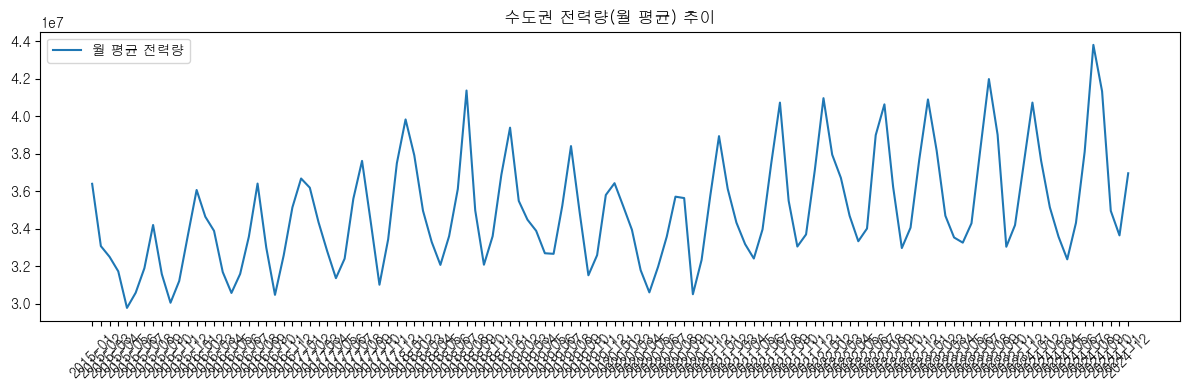

In [457]:
import matplotlib.pyplot as plt

ts = df_sudo_final.groupby("날짜")["전력량"].mean()   # 날짜별 평균

plt.figure(figsize=(12,4))
plt.plot(ts.index, ts.values, label="월 평균 전력량") 
plt.title("수도권 전력량(월 평균) 추이")
plt.xticks(rotation=45)

plt.legend(loc="upper left")
plt.tight_layout()
plt.show()



In [ ]:
# 그룹화를 통해 날씨 데이터 영향 비교 전처리 

features = ['평균기온','강수량','습도','현지기압','수증기기압','풍속','일조율','적설','지면온도']

weather_type = (
    df_sudo_final
    .groupby(["날짜","계약종별"], as_index=False)
    .agg(
        전력량_평균=("전력량","mean"),
        전력량_합계=("전력량","sum"),
        평균기온=("평균기온(°C)","mean"),
        강수량=("월합강수량(00~24h만)(mm)","mean"),
        습도=("평균상대습도(%)","mean"),
        현지기압=("평균현지기압(hPa)","mean"),
        수증기기압=("평균수증기압(hPa)","mean"),
        풍속=("평균풍속(m/s)","mean"),
        일조율=("일조율(%)","mean"),
        적설=("최심적설(cm)","mean"),
        지면온도=("평균지면온도(°C)","mean")
    )
)

weather = (
    df_sudo_final
    .groupby(["날짜"], as_index=False)
    .agg(
        전력량_평균=("전력량","mean"),
        전력량_합계=("전력량","sum"),
        평균기온=("평균기온(°C)","mean"),
        강수량=("월합강수량(00~24h만)(mm)","mean"),
        습도=("평균상대습도(%)","mean"),
        현지기압=("평균현지기압(hPa)","mean"),
        수증기기압=("평균수증기압(hPa)","mean"),
        풍속=("평균풍속(m/s)","mean"),
        일조율=("일조율(%)","mean"),
        적설=("최심적설(cm)","mean"),
        지면온도=("평균지면온도(°C)","mean")
    )
)

In [ ]:
# 월별 그룹화를 통한 날씨 데이터와 전력량 상관관계 분석 (합계 평균 결과 같음)
corr = weather[
    ['전력량_합계',"평균기온","강수량","습도",
     "현지기압","수증기기압","풍속","일조율","적설","지면온도"]
].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("서울시 월별 전력량-날씨 상관관계")
plt.show()


In [ ]:
# 선형 그래프로 날짜 그룹화 + 종별 판단
for idx,name in enumerate(features):
    g = sns.FacetGrid(
        weather_type,
        col="계약종별",
        col_wrap=3,
        height=3,
        sharey=False
    )
    g.map_dataframe(
        sns.regplot,
        x=name,
        y="전력량_합계",
        scatter_kws={"alpha":0.5},
        line_kws={"color":"red"}
    )
    g.fig.suptitle(f"계약종별 {name}-전력량 관계", y=1.03)
    plt.show()

In [ ]:
# pairplot로 나타내기

weather_type = (
    df_final
    .groupby(["날짜","계약종별"], as_index=False)
    .agg(
        전력량_평균=("전력량","mean"),
        전력량_합계=("전력량","sum"),
        평균기온=("평균기온(°C)","mean"),
        강수량=("월합강수량(00~24h만)(mm)","mean"),
        습도=("평균상대습도(%)","mean"),
        현지기압=("평균현지기압(hPa)","mean"),
        수증기기압=("평균수증기압(hPa)","mean"),
        풍속=("평균풍속(m/s)","mean"),
        일조율=("일조율(%)","mean"),
        적설=("최심적설(cm)","mean"),
        지면온도=("평균지면온도(°C)","mean")
    )
)



g = sns.pairplot(weather_type[['전력량_합계','평균기온','강수량','습도','현지기압','수증기기압','풍속','일조율','적설','지면온도']])
g.savefig("pairplot.png", dpi=300, bbox_inches="tight")

In [ ]:
df_final

In [ ]:
df_final.groupby(['계약종별'])['전력량'].mean()

In [ ]:
# 구별 전력량 합계
s = df_final.groupby('시군구')['전력량'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(s.index, s.values)
plt.title('서울시 구별 전력량 합계')
plt.xlabel('전력량 합계')
plt.ylabel('시군구')
plt.tight_layout()
plt.show()


In [ ]:
# 서울시에서 계약종별의  가장 많은 전력량
s = df_final.groupby('계약종별')['전력량'].mean().sort_values()

plt.Figure(figsize=(8,4))
plt.xlabel('평균 전력량')
plt.title('계약종별 - 평균 전력량')
plt.barh(s.index,s.values)
plt.show()


In [ ]:
df_final

In [ ]:
sns.boxplot(x='계약종별', y='전력량', data=df_final)

In [ ]:
top50 = df_final.nlargest(50, '전력량')[['시군구','계약종별','전력량']]
top50

In [ ]:
df = df_final.copy()

# 1) 월×계약종별로 전력량 합계 (구는 합쳐버림)
ts = df.groupby([df.index, '계약종별'])['전력량'].sum().unstack('계약종별')

# 2) PeriodIndex면 matplotlib용 timestamp로 변환
if isinstance(ts.index, pd.PeriodIndex):
    ts_plot = ts.copy()
    ts_plot.index = ts_plot.index.to_timestamp()
else:
    ts_plot = ts

# 3) 그리기
plt.figure(figsize=(16,6))
for col in ts_plot.columns:
    plt.plot(ts_plot.index, ts_plot[col], marker='o', markersize=2, linewidth=1, label=col)

plt.title('계약종별 월별 전력량 추이(서울 전체)')
plt.xlabel('날짜')
plt.ylabel('전력량')
plt.legend(title='계약종별', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
df = df_final.copy()

# 날짜가 인덱스면 컬럼으로 꺼내기
df = df.reset_index().rename(columns={'index': '날짜'})

# 날짜 타입 정리 (월 단위라 가정)
df['날짜'] = pd.to_datetime(df['날짜'])

# =========================
# 1. 구 × 월 × 계약종별 전력량 집계
# =========================
g = (
    df
    .groupby(['날짜', '시군구', '계약종별'])['전력량']
    .sum()
    .reset_index()
)

# =========================
# 2. 구 × 월 전체 전력량
# =========================
total = (
    g
    .groupby(['날짜', '시군구'])['전력량']
    .sum()
    .reset_index(name='전체전력')
)

# =========================
# 3. 일반용 전력량만 추출
# =========================
general = (
    g[g['계약종별'] == '일반용']
    .rename(columns={'전력량': '일반용전력'})
)

# =========================
# 4. 일반용 비율 계산 (ratio)
# =========================
ratio = general.merge(total, on=['날짜', '시군구'])
ratio['일반용비율'] = ratio['일반용전력'] / ratio['전체전력']

# =========================
# 5. 강남구 vs 기타 구 구분
# =========================
ratio['구분'] = ratio['시군구'].apply(
    lambda x: '강남구' if x == '강남구' else '기타 구'
)

# =========================
# 6. 박스플롯 시각화
# =========================
plt.figure(figsize=(6,4))
sns.boxplot(
    x='구분',
    y='일반용비율',
    data=ratio,
    showfliers=False
)

plt.title('강남구 vs 기타 구 : 일반용 전력 비율')
plt.ylabel('일반용 전력 비율')
plt.xlabel('')
plt.tight_layout()
plt.show()



In [ ]:
# 강남구, 중구, 서초구가 전력량 수요가 많음
plt.figure(figsize=(16,6))
sns.scatterplot(x='시군구', y='전력량', data=df_final)
plt.xticks(rotation=45)
plt.xlabel='서울시 구별'
plt.ylabel='전력량'
plt.show()

In [ ]:
weather_df['지점명'].unique()